<a href="https://colab.research.google.com/github/Madhuanabala/deepak-bhaiya_new/blob/classification-models-rdkit/QD%2Bsmote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original dataset shape: (653, 20), (653,)
Resampled dataset shape: (1108, 20), (1108,)
Model: Quadratic Discriminant Analysis with SMOTE
Accuracy: 0.7107142857142857
Balanced Accuracy: 0.7317927170868347
ROC AUC: 0.8212284913965585
F1 Score: 0.4413793103448276
Cohen's Kappa: 0.2900964066608238
Mean Absolute Error: 0.2892857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.70      0.80       238
           1       0.31      0.76      0.44        42

    accuracy                           0.71       280
   macro avg       0.63      0.73      0.62       280
weighted avg       0.85      0.71      0.75       280



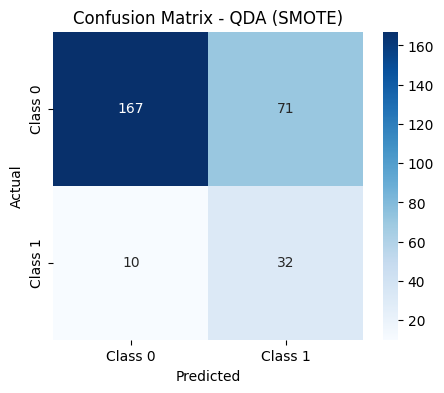

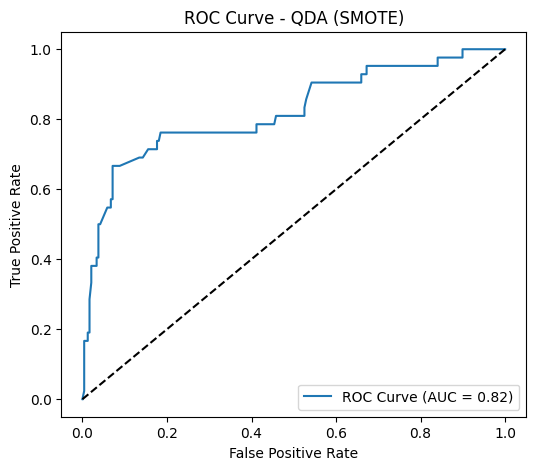

✅ Confusion Matrix saved as 'Confusion_Matrix_QDA_SMOTE.xlsx'
✅ Predictions saved as 'QDA_SMOTE_Predictions.xlsx'
✅ Separate Active/Inactive saved as 'QDA_SMOTE_Active_Inactive.xlsx'


In [1]:
!pip install matplotlib seaborn scikit-learn imbalanced-learn openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, cohen_kappa_score, mean_absolute_error,
    roc_curve
)
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE



df = pd.read_csv("/content/MACCS2_Trainset_top20.csv")

X = df.drop(columns=["BioactivityClass"])
y = df["BioactivityClass"]


if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)
    label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("Label Mapping:", label_mapping)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original dataset shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled dataset shape: {X_train_res.shape}, {y_train_res.shape}")


model = QuadraticDiscriminantAnalysis()
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


print("Model: Quadratic Discriminant Analysis with SMOTE")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("F1 Score:", f1_score(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - QDA (SMOTE)')
plt.show()


cm_df = pd.DataFrame(cm, index=['Actual_0', 'Actual_1'], columns=['Pred_0', 'Pred_1'])
cm_df.to_excel("Confusion_Matrix_QDA_SMOTE.xlsx", index=True)

# ROC Curve Plot
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - QDA (SMOTE)')
plt.legend(loc='lower right')
plt.show()


pred_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Probability": y_prob
})


pred_df.to_excel("QDA_SMOTE_Predictions.xlsx", index=False)


active_df = pred_df[pred_df["Predicted"] == 1]
inactive_df = pred_df[pred_df["Predicted"] == 0]

with pd.ExcelWriter("QDA_SMOTE_Active_Inactive.xlsx") as writer:
    active_df.to_excel(writer, sheet_name="Active", index=False)
    inactive_df.to_excel(writer, sheet_name="Inactive", index=False)

print("✅ Confusion Matrix saved as 'Confusion_Matrix_QDA_SMOTE.xlsx'")
print("✅ Predictions saved as 'QDA_SMOTE_Predictions.xlsx'")
print("✅ Separate Active/Inactive saved as 'QDA_SMOTE_Active_Inactive.xlsx'")
